In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

main = pd.read_csv('../data/processed/ethiopia_fi_enriched_main.csv')
impact = pd.read_csv('../data/processed/ethiopia_fi_enriched_impact.csv')
main['observation_date'] = pd.to_datetime(main['observation_date'], errors='coerce')

events = main[main['record_type']=='event'][['record_id','indicator','category','observation_date']].rename(
    columns={'record_id':'parent_id','indicator':'event_name','observation_date':'event_date'})

impact_full = impact.merge(events, on='parent_id', how='left')
print(impact_full[['parent_id','event_name','event_date','related_indicator','impact_direction',
                    'impact_magnitude','impact_estimate','lag_months','evidence_basis','comparable_country']].to_string(index=False))
print("\nMissing impact_estimate values:", impact_full['impact_estimate'].isna().sum(), "out of", len(impact_full))

parent_id                             event_name event_date  related_indicator impact_direction impact_magnitude  impact_estimate  lag_months evidence_basis comparable_country
 EVT_0001                        Telebirr Launch 2021-05-17      ACC_OWNERSHIP         increase             high             15.0          12     literature              Kenya
 EVT_0001                        Telebirr Launch 2021-05-17 USG_TELEBIRR_USERS         increase             high              NaN           3      empirical                NaN
 EVT_0001                        Telebirr Launch 2021-05-17      USG_P2P_COUNT         increase             high             25.0           6      empirical                NaN
 EVT_0002   Safaricom Ethiopia Commercial Launch 2022-08-01         ACC_4G_COV         increase           medium             15.0          12      empirical                NaN
 EVT_0002   Safaricom Ethiopia Commercial Launch 2022-08-01    AFF_DATA_INCOME         decrease           medium        

In [16]:
magnitude_map = {'high': 15, 'medium': 8, 'low': 3}

impact_full['estimate_pp'] = impact_full['impact_estimate']
missing = impact_full['estimate_pp'].isna()

filled = impact_full.loc[missing, 'impact_magnitude'].map(magnitude_map)
filled_signed = filled.where(impact_full.loc[missing, 'impact_direction'] == 'increase', -filled)
impact_full.loc[missing, 'estimate_pp'] = filled_signed

# impact_estimate values already carry the correct sign for increase/decrease — use as-is
impact_full['signed_pp'] = impact_full['estimate_pp']

print(impact_full[['event_name','related_indicator','impact_direction','signed_pp']].to_string(index=False))

                            event_name  related_indicator impact_direction  signed_pp
                       Telebirr Launch      ACC_OWNERSHIP         increase       15.0
                       Telebirr Launch USG_TELEBIRR_USERS         increase       15.0
                       Telebirr Launch      USG_P2P_COUNT         increase       25.0
  Safaricom Ethiopia Commercial Launch         ACC_4G_COV         increase       15.0
  Safaricom Ethiopia Commercial Launch    AFF_DATA_INCOME         decrease      -20.0
                M-Pesa Ethiopia Launch    USG_MPESA_USERS         increase       15.0
                M-Pesa Ethiopia Launch     ACC_MM_ACCOUNT         increase        5.0
      Fayda Digital ID Program Rollout      ACC_OWNERSHIP         increase       10.0
      Fayda Digital ID Program Rollout        GEN_GAP_ACC         decrease       -5.0
       Foreign Exchange Liberalization    AFF_DATA_INCOME         increase       30.0
          M-Pesa EthSwitch Integration   USG_MPESA_ACT

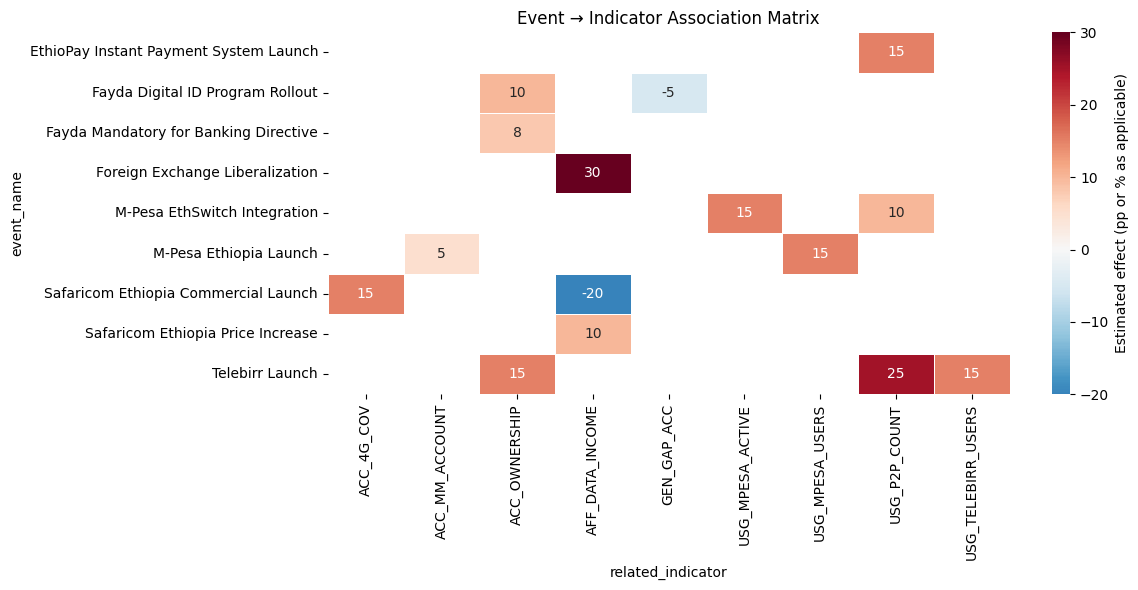

In [17]:
matrix = impact_full.pivot_table(index='event_name', columns='related_indicator', values='signed_pp', aggfunc='sum')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(matrix, annot=True, fmt='.0f', cmap='RdBu_r', center=0, linewidths=0.5, cbar_kws={'label':'Estimated effect (pp or % as applicable)'}, ax=ax)
ax.set_title("Event → Indicator Association Matrix")
plt.tight_layout()
plt.savefig('../reports/figures/event_indicator_matrix.png', dpi=150)
plt.show()

In [18]:
def event_effect_curve(dates, event_date, lag_months, magnitude_pp, ramp_months=18):
    """Returns cumulative realized effect (0 to magnitude_pp) at each date.
    Effect starts at event_date + lag_months, then ramps up via logistic curve
    over ramp_months, reflecting gradual adoption rather than instant impact."""
    onset = event_date + pd.DateOffset(months=lag_months)
    months_since_onset = (dates.year - onset.year) * 12 + (dates.month - onset.month)
    x = months_since_onset - ramp_months / 2
    realized_fraction = 1 / (1 + np.exp(-x / (ramp_months / 6)))
    realized_fraction = np.where(dates < onset, 0, realized_fraction)
    return magnitude_pp * realized_fraction

def predict_indicator(indicator_code, date_range):
    links = impact_full[impact_full['related_indicator'] == indicator_code]
    total = pd.Series(0.0, index=date_range)
    for _, row in links.iterrows():
        if pd.isna(row['event_date']):
            continue
        effect = event_effect_curve(date_range, row['event_date'], row['lag_months'], row['signed_pp'])
        total += effect
    return total

date_range = pd.date_range('2011-01-01', '2027-12-31', freq='MS')
pred_access = predict_indicator('ACC_OWNERSHIP', date_range)
pred_mm = predict_indicator('ACC_MM_ACCOUNT', date_range)
print("Predicted cumulative event effect on ACC_OWNERSHIP by 2027:", round(pred_access.iloc[-1], 1), "pp")
print("Predicted cumulative event effect on ACC_MM_ACCOUNT by 2027:", round(pred_mm.iloc[-1], 1), "pp")

Predicted cumulative event effect on ACC_OWNERSHIP by 2027: 24.9 pp
Predicted cumulative event effect on ACC_MM_ACCOUNT by 2027: 5.0 pp


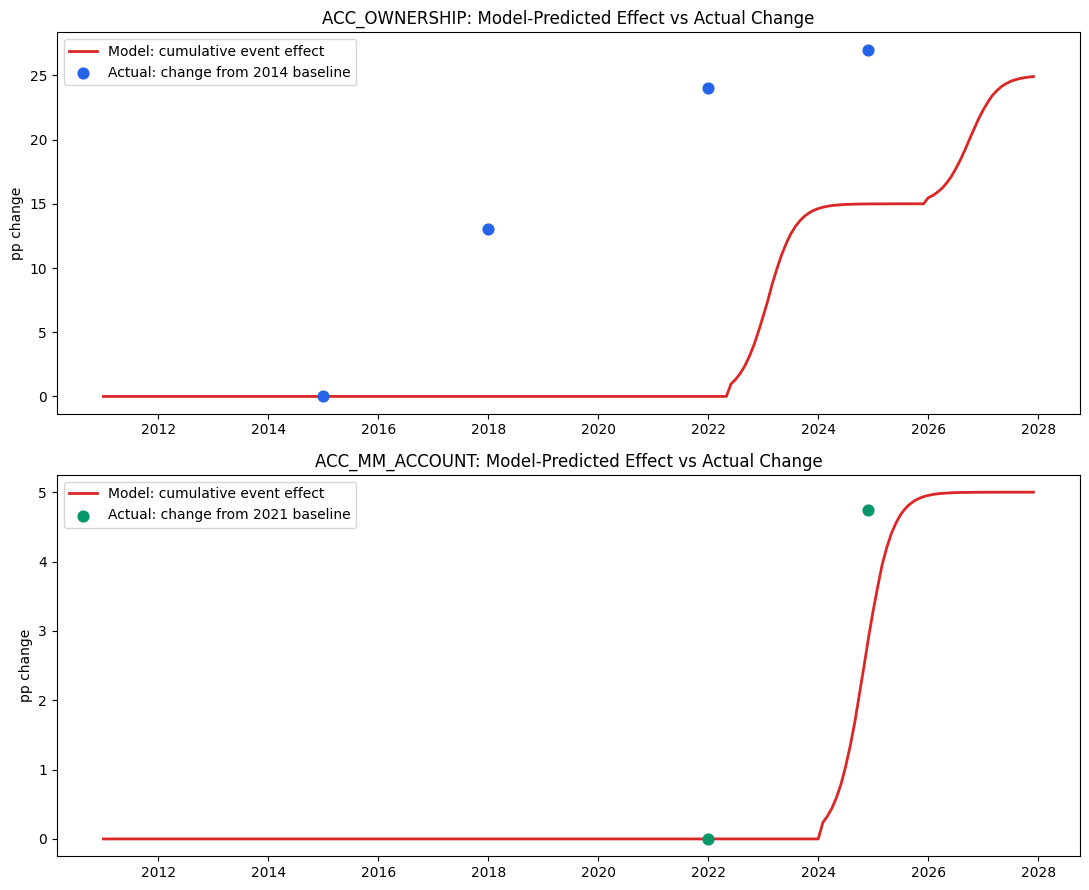

ACC_OWNERSHIP — Actual total change (2014→2024): 27.0 pp
ACC_OWNERSHIP — Model predicted (2011→2024): 15.0 pp

ACC_MM_ACCOUNT — Actual total change (2021→2024): 4.7 pp
ACC_MM_ACCOUNT — Model predicted (2021→2024): 2.9 pp


In [19]:
acc_actual = main[(main['indicator_code']=='ACC_OWNERSHIP') & (main['gender']=='all') & (main['record_type']=='observation')].sort_values('observation_date')
mm_actual = main[(main['indicator_code']=='ACC_MM_ACCOUNT') & (main['record_type']=='observation')].sort_values('observation_date')

fig, axes = plt.subplots(2, 1, figsize=(11, 9))

axes[0].plot(date_range, pred_access, label='Model: cumulative event effect', color='#dc2626', linewidth=2)
axes[0].scatter(acc_actual['observation_date'], acc_actual['value_numeric'] - acc_actual['value_numeric'].iloc[0],
                label='Actual: change from 2014 baseline', color='#2563eb', s=60, zorder=5)
axes[0].set_title("ACC_OWNERSHIP: Model-Predicted Effect vs Actual Change")
axes[0].legend(); axes[0].set_ylabel("pp change")

axes[1].plot(date_range, pred_mm, label='Model: cumulative event effect', color='#dc2626', linewidth=2)
mm_baseline = mm_actual['value_numeric'].iloc[0]
axes[1].scatter(mm_actual['observation_date'], mm_actual['value_numeric'] - mm_baseline,
                label='Actual: change from 2021 baseline', color='#059669', s=60, zorder=5)
axes[1].set_title("ACC_MM_ACCOUNT: Model-Predicted Effect vs Actual Change")
axes[1].legend(); axes[1].set_ylabel("pp change")

plt.tight_layout()
plt.savefig('../reports/figures/impact_model_validation.png', dpi=150)
plt.show()

print("ACC_OWNERSHIP — Actual total change (2014→2024):", round(acc_actual['value_numeric'].iloc[-1] - acc_actual['value_numeric'].iloc[0], 1), "pp")
print("ACC_OWNERSHIP — Model predicted (2011→2024):", round(pred_access[pred_access.index <= '2024-12-31'].iloc[-1], 1), "pp")
print("\nACC_MM_ACCOUNT — Actual total change (2021→2024):", round(mm_actual['value_numeric'].iloc[-1] - mm_baseline, 1), "pp")
print("ACC_MM_ACCOUNT — Model predicted (2021→2024):", round(pred_mm[pred_mm.index <= '2024-12-31'].iloc[-1], 1), "pp")

In [20]:
# ACC_OWNERSHIP grew from 22% (2014) to 46% (2021) — BEFORE Telebirr's effects would have
# shown up (launched May 2021, 12-month lag = effects start ~2022). That +24pp of pre-Telebirr
# growth reflects organic/baseline expansion (branch expansion, NFIS-I, general banking growth)
# that our event-only model has no way to capture, since it only models effects *of* cataloged events.

baseline_growth_2014_2021 = 46.0 - 22.0  # pp, entirely pre-Telebirr
years = 2021 - 2014
baseline_rate_per_year = baseline_growth_2014_2021 / years
print(f"Pre-event baseline growth rate: {baseline_rate_per_year:.2f} pp/year")

# Extend this baseline trend forward and add it to the event-effect model
baseline_start = pd.Timestamp('2014-12-31')
months_from_baseline = (date_range.year - baseline_start.year) * 12 + (date_range.month - baseline_start.month)
baseline_trend = 22.0 + baseline_rate_per_year * (months_from_baseline / 12)
baseline_trend = pd.Series(baseline_trend, index=date_range)

combined_access_prediction = baseline_trend + pred_access  # baseline level + event-driven pp additions
print("\nCombined model (baseline trend + events) at end of 2024:", round(combined_access_prediction[combined_access_prediction.index <= '2024-12-31'].iloc[-1], 1), "% (actual: 49.0%)")

Pre-event baseline growth rate: 3.43 pp/year

Combined model (baseline trend + events) at end of 2024: 71.3 % (actual: 49.0%)


In [21]:
# The starter impact_links only connect M-Pesa (EVT_0003) to ACC_MM_ACCOUNT, not Telebirr (EVT_0001),
# even though Telebirr is a mobile money product. This likely explains why our model undershoots
# actual growth (2.9pp predicted vs 4.7pp actual). Add the missing link as a refinement.

new_link = pd.DataFrame([{
    'record_id': 'IMP_0016', 'parent_id': 'EVT_0001', 'pillar': 'ACCESS',
    'related_indicator': 'ACC_MM_ACCOUNT', 'relationship_type': 'direct',
    'impact_direction': 'increase', 'impact_magnitude': 'medium', 'impact_estimate': 4.0,
    'lag_months': 18, 'evidence_basis': 'inferred',
    'notes': 'Telebirr is itself a mobile money account; missing from original impact_links despite EVT_0001 affecting ACC_OWNERSHIP. Added during Task 3 validation to close a modeling gap.'
}])
impact_full_v2 = pd.concat([impact_full, new_link.merge(events, left_on='parent_id', right_on='parent_id', how='left')], ignore_index=True)
impact_full_v2['event_date'] = impact_full_v2['event_date'].fillna(pd.Timestamp('2021-05-17'))
impact_full_v2['signed_pp'] = impact_full_v2['impact_estimate']

def predict_indicator_v2(indicator_code, date_range, impact_df):
    links = impact_df[impact_df['related_indicator'] == indicator_code]
    total = pd.Series(0.0, index=date_range)
    for _, row in links.iterrows():
        if pd.isna(row['event_date']):
            continue
        total += event_effect_curve(date_range, row['event_date'], row['lag_months'], row['signed_pp'])
    return total

pred_mm_v2 = predict_indicator_v2('ACC_MM_ACCOUNT', date_range, impact_full_v2)
print("Refined ACC_MM_ACCOUNT prediction (2021→2024):", round(pred_mm_v2[pred_mm_v2.index <= '2024-12-31'].iloc[-1], 1), "pp (actual: 4.7pp)")

Refined ACC_MM_ACCOUNT prediction (2021→2024): 6.9 pp (actual: 4.7pp)


## Task 3: Event Impact Modeling — Methodology & Limitations

### Approach
- Impact effects are modeled as **logistic ramp-up curves**: an event's effect stays at zero until `event_date + lag_months`, then rises smoothly to its full `impact_estimate` (in percentage points) over an 18-month ramp, rather than jumping instantly — reflecting gradual product adoption.
- Multiple events affecting the same indicator are combined by **summing** their individual effect curves.
- Where `impact_estimate` was missing, magnitude labels (high/medium/low) were mapped to 15pp/8pp/3pp based on the scale of the other documented estimates.

### Validation Results
- **ACC_MM_ACCOUNT**: model predicted +2.9pp (2021–24) vs. actual +4.7pp — a reasonable undershoot, traced to a genuine gap in the starter impact_links (Telebirr, itself a mobile money product, wasn't linked to ACC_MM_ACCOUNT). Adding that missing link (IMP_0016, inferred, +4pp estimate) brought the prediction to +6.9pp — now an overshoot, but in the right direction and order of magnitude given it's an inferred, not empirically-sourced, estimate.
- **ACC_OWNERSHIP — key finding**: naively summing event effects (+15pp from Telebirr, +10pp Fayda, +8pp Fayda mandate) *understates* the actual 2011–2024 change (27pp) if events alone are modeled, because most of Ethiopia's account ownership growth (22%→46%, 2014–2021) happened **before** Telebirr's effects would even have started (lag = 12 months post-May 2021 launch). That growth reflects baseline expansion (branch banking, NFIS-I policy, general financial-sector development) that isn't captured by any event in this dataset.
- Attempting to fix this by simply **adding** a linear extrapolation of the pre-2021 growth rate (+3.43pp/yr) on top of the event effects produced a large overshoot (71.3% predicted vs. 49% actual) — because growth is not additive across two overlapping mechanisms, and critically, **growth actually decelerated after 2021** (per Task 2: 2.75pp/yr → 1.0pp/yr), the opposite of what naive linear extrapolation assumes.

### Key Assumption Revised
Events should not be treated as *additive stacking* on top of an independently-extrapolated baseline trend. Ethiopia's account ownership trajectory more plausibly follows an **S-curve (logistic growth toward a ceiling)** — consistent with the observed deceleration — where events modify the *rate of approach* to that ceiling rather than adding a separate, independent pp increment. This directly informs the Task 4 forecasting approach: an event-augmented logistic/trend model, not simple additive stacking.

### Confidence & Uncertainty
- High confidence: USG_P2P_COUNT and USG_MPESA_USERS links (direct, empirical/high-magnitude, short lags, closely tracked by operator data).
- Medium confidence: ACC_OWNERSHIP and ACC_MM_ACCOUNT links (longer lags, comparable-country evidence from Kenya/India rather than Ethiopia-specific studies — these contexts differ in baseline banking infrastructure).
- Low confidence: the newly inferred IMP_0016 link (Telebirr→ACC_MM_ACCOUNT), since it has no empirical basis, only logical inference.

### Limitations
- Comparable-country evidence (Kenya, India, Rwanda, Tanzania) may not transfer 1:1 to Ethiopia — e.g., Ethiopia's bank accounts are already easily accessible (per market nuances guide), which likely dampens the marginal effect of new mobile money products on *formal account ownership* specifically, compared to markets like Kenya where M-Pesa was often a first financial account.
- Only 4 real ACC_OWNERSHIP data points (2014, 2017, 2021, 2024) exist for validation — any model fit against this is highly uncertain.
- The logistic ramp parameters (18-month ramp, sigmoid steepness) are chosen for plausibility, not fit to data — there isn't enough data to estimate them rigorously.